# 2 多层感知机

## 2.1 理论计算题

### 题目 1：非线性激活函数的重要性

**问题：** 假设一个具有单隐藏层的多层感知机，输入为 $x$，隐藏层没有激活函数（即线性激活），表达为 $h = W_1 x + b_1$，输出层为 $o = W_2 h + b_2$。请通过代数推导证明，该网络等价于一个单层神经网络，并写出等价后的权重矩阵 $W'$ 和偏置向量 $b'$。

---

**解答：**

将隐藏层表达式代入输出层：

$$o = W_2 h + b_2 = W_2 (W_1 x + b_1) + b_2$$

展开：

$$o = W_2 W_1 x + W_2 b_1 + b_2$$

令：

$$W' = W_2 W_1$$

$$b' = W_2 b_1 + b_2$$

则有：

$$o = W' x + b'$$

这是一个标准的单层线性神经网络表达式。因此，**没有非线性激活函数的多层感知机等价于一个单层线性神经网络**。

**结论：** 非线性激活函数（如 ReLU、Sigmoid、tanh 等）是深度神经网络能够学习复杂非线性映射的关键。缺少非线性激活函数时，无论网络有多少层，其表达能力都退化为线性模型。

### 题目 2：激活函数性质分析

**问题：** 写出 $\text{Sigmoid}(x)$ 和 $\tanh(x)$ 的数学表达式，并推导它们的导数 $\text{Sigmoid}'(x)$ 和 $\tanh'(x)$ 与其函数自身的关系。

---

**解答：**

#### Sigmoid 函数

**数学表达式：**

$$\sigma(x) = \text{Sigmoid}(x) = \frac{1}{1 + e^{-x}}$$

**导数推导：**

$$\begin{aligned}
\sigma'(x) &= \frac{d}{dx}\left(\frac{1}{1 + e^{-x}}\right) \\
&= -\frac{1}{(1 + e^{-x})^2} \cdot (-e^{-x}) \\
&= \frac{e^{-x}}{(1 + e^{-x})^2} \\
&= \frac{1}{1 + e^{-x}} \cdot \frac{e^{-x}}{1 + e^{-x}} \\
&= \sigma(x) \cdot (1 - \sigma(x))
\end{aligned}$$

**导数与自身关系：** $\sigma'(x) = \sigma(x)(1 - \sigma(x))$

---

#### Tanh 函数

**数学表达式：**

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} = \frac{e^{2x} - 1}{e^{2x} + 1}$$

**导数推导：**

方法一：利用商法则

$$\begin{aligned}
\tanh'(x) &= \frac{(e^x + e^{-x})(e^x + e^{-x}) - (e^x - e^{-x})(e^x - e^{-x})}{(e^x + e^{-x})^2} \\
&= \frac{(e^x + e^{-x})^2 - (e^x - e^{-x})^2}{(e^x + e^{-x})^2} \\
&= 1 - \frac{(e^x - e^{-x})^2}{(e^x + e^{-x})^2} \\
&= 1 - \tanh^2(x)
\end{aligned}$$

方法二：利用 $\tanh(x) = 2\sigma(2x) - 1$ 关系

$$\tanh'(x) = 4\sigma'(2x) = 4\sigma(2x)(1 - \sigma(2x)) = 1 - \tanh^2(x)$$

**导数与自身关系：** $\tanh'(x) = 1 - \tanh^2(x)$

## 2.2 编程题：从零实现 MLP

不使用深度学习框架的高级 API，纯 PyTorch 基础算子从零实现一个多分类单隐藏层 MLP，使用 Fashion-MNIST 数据集。

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import time

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# 设备选择
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

Missing colon in file WindowsPath('D:/develop/Anaconda/anaconda3/envs/yangyang/lib/site-packages/matplotlib/mpl-data/matplotlibrc'), line 413 (' use Unicode for the minus symbol rather than hyphen.  See')


使用设备: cpu


训练集大小: 60000
测试集大小: 10000


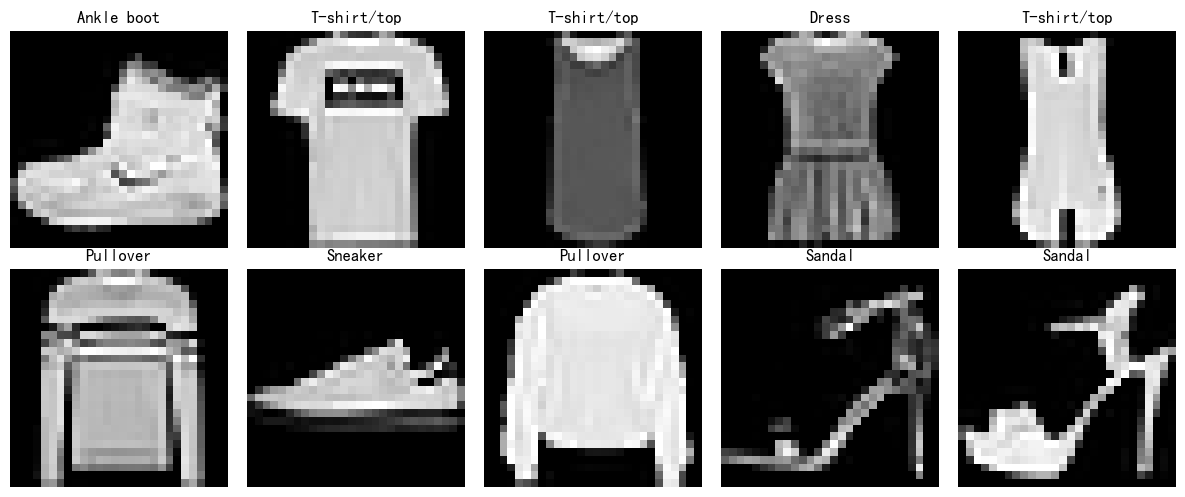

In [2]:
# =============================================
# 1. 加载 Fashion-MNIST 数据集
# =============================================
batch_size = 256

# 将图像展平为 784 维向量，并归一化到 [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # 归一化到 [-1, 1]
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False)

print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")

# 类别名称
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 可视化一些样本
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(class_names[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [3]:
# =============================================
# 2. 手动初始化参数（正态分布随机初始化）
# =============================================
input_dim = 784   # 28x28
hidden_dim = 256  # 隐藏层大小
output_dim = 10   # 10 个类别

# 正态分布初始化
W1 = torch.randn(input_dim, hidden_dim, device=device) * 0.01
b1 = torch.zeros(hidden_dim, device=device)
W2 = torch.randn(hidden_dim, output_dim, device=device) * 0.01
b2 = torch.zeros(output_dim, device=device)

print(f"W1 shape: {W1.shape}, b1 shape: {b1.shape}")
print(f"W2 shape: {W2.shape}, b2 shape: {b2.shape}")
print(f"W1 mean={W1.mean().item():.6f}, std={W1.std().item():.6f}")
print(f"W2 mean={W2.mean().item():.6f}, std={W2.std().item():.6f}")

W1 shape: torch.Size([784, 256]), b1 shape: torch.Size([256])
W2 shape: torch.Size([256, 10]), b2 shape: torch.Size([10])
W1 mean=-0.000004, std=0.010039
W2 mean=0.000157, std=0.009948


In [4]:
# =============================================
# 3. 实现 ReLU 激活函数的前向传播: max(0, x)
# =============================================
def relu(x):
    """ReLU 激活函数: max(0, x)"""
    return torch.clamp(x, min=0)

# 测试
x_test = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
print(f"ReLU({x_test}) = {relu(x_test)}")
print(f"与 PyTorch 内置一致: {torch.allclose(relu(x_test), torch.relu(x_test))}")

ReLU(tensor([-2., -1.,  0.,  1.,  2.])) = tensor([0., 0., 0., 1., 2.])
与 PyTorch 内置一致: True


In [5]:
# =============================================
# 4. 实现带有 Softmax 的交叉熵损失函数
# =============================================
def softmax(logits):
    """数值稳定的 Softmax 函数"""
    # 减去最大值防止数值溢出
    logits_max = torch.max(logits, dim=1, keepdim=True).values
    exp_logits = torch.exp(logits - logits_max)
    return exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)

def cross_entropy_loss(logits, labels):
    """
    带有 Softmax 的交叉熵损失函数
    logits: (batch_size, num_classes)
    labels: (batch_size,) 整数标签
    """
    batch_size = logits.shape[0]
    probs = softmax(logits)
    # 取出正确类别的概率
    correct_probs = probs[range(batch_size), labels]
    # 计算交叉熵损失
    loss = -torch.log(correct_probs + 1e-8).mean()  # 加 epsilon 防止 log(0)
    return loss, probs

# 测试
test_logits = torch.randn(4, 10)
test_labels = torch.randint(0, 10, (4,))
test_loss, test_probs = cross_entropy_loss(test_logits, test_labels)
print(f"测试损失: {test_loss.item():.4f}")
print(f"概率和: {test_probs.sum(dim=1)}")

# 与 PyTorch 内置函数对比
torch_loss = torch.nn.functional.cross_entropy(test_logits, test_labels)
print(f"PyTorch 内置损失: {torch_loss.item():.4f}")
print(f"两者一致: {torch.allclose(test_loss, torch_loss, atol=1e-4)}")

测试损失: 3.5917
概率和: tensor([1.0000, 1.0000, 1.0000, 1.0000])
PyTorch 内置损失: 3.5917
两者一致: True


In [6]:
# =============================================
# 5. 前向传播函数
# =============================================
def forward(x, W1, b1, W2, b2, is_training=True):
    """
    单隐藏层 MLP 前向传播
    x: (batch_size, input_dim)
    """
    # 隐藏层
    h = torch.matmul(x, W1) + b1  # (batch_size, hidden_dim)
    h = relu(h)                    # ReLU 激活

    # 输出层
    logits = torch.matmul(h, W2) + b2  # (batch_size, output_dim)

    return logits

def predict(x, W1, b1, W2, b2):
    """预测类别"""
    logits = forward(x, W1, b1, W2, b2, is_training=False)
    return torch.argmax(logits, dim=1)

def accuracy(x, labels, W1, b1, W2, b2):
    """计算准确率"""
    preds = predict(x, W1, b1, W2, b2)
    return (preds == labels).float().mean().item()

In [7]:
# =============================================
# 6. 编写训练循环（Mini-batch SGD 手动更新参数）
# =============================================
num_epochs = 20
learning_rate = 0.1

# 记录训练历史
train_losses = []
train_accs = []
test_losses = []
test_accs = []

# 将整个测试集转换为 tensor（方便评估）
test_images = test_dataset.data.float().reshape(-1, 784).to(device) / 255.0
test_images = (test_images - 0.5) / 0.5  # 与训练集相同归一化
test_labels = test_dataset.targets.to(device)

print("开始训练...")
start_time = time.time()

for epoch in range(num_epochs):
    epoch_loss = 0.0
    epoch_acc = 0.0
    num_batches = 0

    for batch_x, batch_y in train_loader:
        # 展平图像
        batch_x = batch_x.reshape(-1, input_dim).to(device)
        batch_y = batch_y.to(device)

        # 前向传播
        logits = forward(batch_x, W1, b1, W2, b2)
        loss, _ = cross_entropy_loss(logits, batch_y)

        # 手动计算梯度（反向传播）
        # dL/d(logits) = softmax - one_hot
        probs = softmax(logits)
        batch_size_actual = batch_x.shape[0]
        one_hot = torch.zeros_like(probs)
        one_hot[range(batch_size_actual), batch_y] = 1
        dlogits = (probs - one_hot) / batch_size_actual  # (batch_size, output_dim)

        # dL/dW2 = h^T @ dlogits
        h = relu(torch.matmul(batch_x, W1) + b1)
        dW2 = torch.matmul(h.T, dlogits)  # (hidden_dim, output_dim)
        db2 = dlogits.sum(dim=0)          # (output_dim,)

        # dL/dh = dlogits @ W2^T
        dh = torch.matmul(dlogits, W2.T)  # (batch_size, hidden_dim)
        # ReLU 的导数: x > 0 时为 1, 否则为 0
        dh[h <= 0] = 0

        # dL/dW1 = x^T @ dh
        dW1 = torch.matmul(batch_x.T, dh)  # (input_dim, hidden_dim)
        db1 = dh.sum(dim=0)                # (hidden_dim,)

        # SGD 更新参数
        with torch.no_grad():
            W1 -= learning_rate * dW1
            b1 -= learning_rate * db1
            W2 -= learning_rate * dW2
            b2 -= learning_rate * db2

        epoch_loss += loss.item()
        epoch_acc += (torch.argmax(logits, dim=1) == batch_y).float().mean().item()
        num_batches += 1

    avg_train_loss = epoch_loss / num_batches
    avg_train_acc = epoch_acc / num_batches

    # 测试集评估
    with torch.no_grad():
        test_logits = forward(test_images, W1, b1, W2, b2, is_training=False)
        test_loss, _ = cross_entropy_loss(test_logits, test_labels)
        test_acc = accuracy(test_images, test_labels, W1, b1, W2, b2)

    train_losses.append(avg_train_loss)
    train_accs.append(avg_train_acc)
    test_losses.append(test_loss.item())
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1:3d}/{num_epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f} | "
          f"Test Loss: {test_loss.item():.4f} | Test Acc: {test_acc:.4f}")

elapsed = time.time() - start_time
print(f"\n训练完成！总耗时: {elapsed:.2f} 秒")
print(f"最终测试准确率: {test_accs[-1]:.4f}")

开始训练...
Epoch   1/20 | Train Loss: 0.7690 | Train Acc: 0.7290 | Test Loss: 0.5599 | Test Acc: 0.7931
Epoch   2/20 | Train Loss: 0.4896 | Train Acc: 0.8214 | Test Loss: 0.5128 | Test Acc: 0.8065
Epoch   3/20 | Train Loss: 0.4421 | Train Acc: 0.8405 | Test Loss: 0.4654 | Test Acc: 0.8311
Epoch   4/20 | Train Loss: 0.4064 | Train Acc: 0.8533 | Test Loss: 0.4546 | Test Acc: 0.8358
Epoch   5/20 | Train Loss: 0.3852 | Train Acc: 0.8596 | Test Loss: 0.4412 | Test Acc: 0.8410
Epoch   6/20 | Train Loss: 0.3674 | Train Acc: 0.8677 | Test Loss: 0.4026 | Test Acc: 0.8547
Epoch   7/20 | Train Loss: 0.3571 | Train Acc: 0.8714 | Test Loss: 0.4067 | Test Acc: 0.8503
Epoch   8/20 | Train Loss: 0.3453 | Train Acc: 0.8753 | Test Loss: 0.4254 | Test Acc: 0.8448
Epoch   9/20 | Train Loss: 0.3328 | Train Acc: 0.8801 | Test Loss: 0.3774 | Test Acc: 0.8667
Epoch  10/20 | Train Loss: 0.3225 | Train Acc: 0.8828 | Test Loss: 0.3834 | Test Acc: 0.8608
Epoch  11/20 | Train Loss: 0.3157 | Train Acc: 0.8853 | Test L

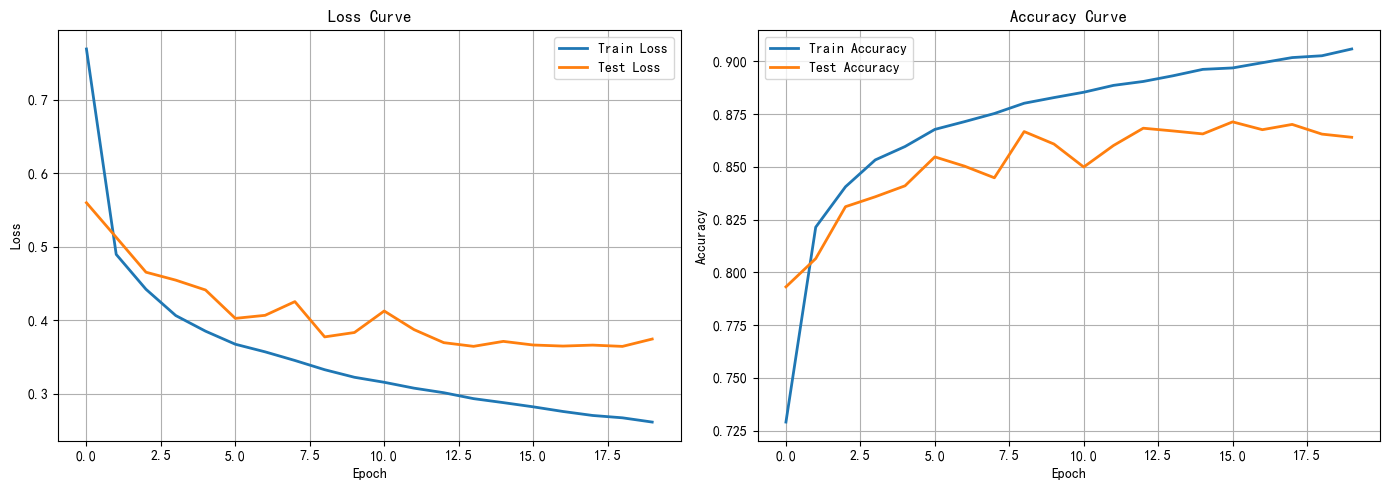

In [8]:
# 绘制训练曲线
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', linewidth=2)
ax1.plot(test_losses, label='Test Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs, label='Train Accuracy', linewidth=2)
ax2.plot(test_accs, label='Test Accuracy', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

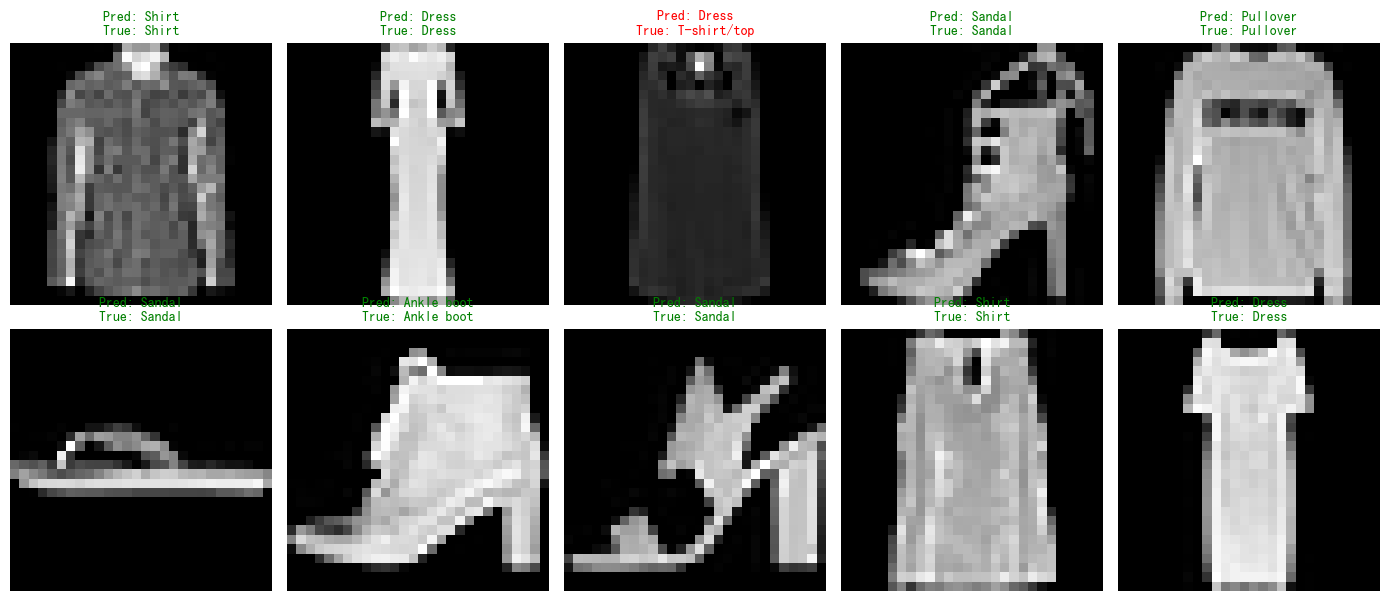

In [9]:
# 可视化一些预测结果
def show_predictions(W1, b1, W2, b2, num_samples=10):
    indices = np.random.choice(len(test_dataset), num_samples, replace=False)
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))

    for i, idx in enumerate(indices):
        img, true_label = test_dataset[idx]
        x = img.reshape(1, -1).to(device)
        with torch.no_grad():
            logits = forward(x, W1, b1, W2, b2, is_training=False)
            pred = torch.argmax(logits, dim=1).item()

        ax = axes.flat[i]
        ax.imshow(img.squeeze(), cmap='gray')
        color = 'green' if pred == true_label else 'red'
        ax.set_title(f'Pred: {class_names[pred]}\nTrue: {class_names[true_label]}',
                     color=color, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_predictions(W1, b1, W2, b2)

# 3 模型选择，权重衰减和丢弃法

## 3.1 理论计算题

### 题目 1：过拟合与欠拟合

**问题：** 简述训练误差（Training Error）与泛化误差（Generalization Error）的区别。当一个模型的训练误差极低，但泛化误差很高时，模型处于什么状态？应该如何通过控制模型复杂度来缓解这一现象？

---

**解答：**

#### 训练误差 vs 泛化误差

| 项目 | 训练误差 (Training Error) | 泛化误差 (Generalization Error) |
|---|---|---|
| **定义** | 模型在训练数据集上的预测误差 | 模型在未见过的测试数据上的预测误差 |
| **测量对象** | 已见过的样本 | 未见过的新样本 |
| **反映能力** | 模型对训练数据的拟合程度 | 模型的真实预测能力/泛化能力 |

#### 过拟合状态分析

当训练误差极低而泛化误差很高时，模型处于**过拟合（Overfitting）**状态。

**原因：** 模型过度学习了训练数据中的噪声和细节模式，而非数据背后的本质规律，导致对新数据的泛化能力差。

#### 缓解过拟合的方法（通过控制模型复杂度）

1. **减少模型参数数量：** 降低隐藏层数量或隐藏单元数，减少模型容量。
2. **权重衰减（L2 正则化）：** 在损失函数中加入 $\lambda \|W\|_2^2$，限制权重大小，使模型更加平滑。
3. **Dropout：** 训练时随机丢弃部分神经元，相当于训练多个子网络的集成。
4. **早停（Early Stopping）：** 在验证误差开始上升时停止训练。
5. **数据增强：** 增加训练数据的多样性，提高泛化能力。
6. **简化模型结构：** 选择更简单的模型架构。

**欠拟合（Underfitting）** 则相反，训练误差和泛化误差都很高，说明模型容量不足，应增加模型复杂度。

### 题目 2：K 折交叉验证

**问题：** 阐述 K 折交叉验证（K-fold Cross-Validation）的具体实施算法步骤。

---

**解答：**

#### K 折交叉验证算法步骤

**输入：** 训练数据集 $D$，折数 $K$，模型训练算法

**算法步骤：**

1. **数据划分：** 将训练数据 $D$ 随机均匀划分为 $K$ 个互不相交的子集 $D_1, D_2, \ldots, D_K$，每个子集大小大致相等。

2. **循环验证：** 对 $k = 1, 2, \ldots, K$：
   - **(a)** 将第 $k$ 个子集 $D_k$ 作为**验证集**（Validation Set）。
   - **(b)** 将剩余的 $K-1$ 个子集的并集作为**训练集**（Training Set）。
   - **(c)** 在训练集上训练模型，得到模型 $M_k$。
   - **(d)** 在验证集 $D_k$ 上评估模型 $M_k$，记录验证误差 $\epsilon_k$。

3. **汇总结果：** 计算 $K$ 次验证误差的平均值作为模型的最终性能估计：
   $$\bar{\epsilon} = \frac{1}{K} \sum_{k=1}^{K} \epsilon_k$$

4. **模型选择（可选）：** 选择使 $\bar{\epsilon}$ 最小的超参数配置，然后用全部 $K$ 折数据重新训练最终模型。

**常用的 K 值：** $K=5$ 或 $K=10$（5 折或 10 折交叉验证）。

**特殊情形：**
- 当 $K = N$（样本总数）时，称为**留一交叉验证（Leave-One-Out Cross-Validation, LOOCV）**，计算成本较高但偏差最小。

**优点：**
- 充分利用有限数据
- 每个样本恰好被用作一次验证
- 减少了因数据划分随机性带来的评估方差

## 3.2 编程题：L2 正则化 + Dropout

在之前实现的 MLP 上，加入 L2 正则化和 Dropout 机制。

In [10]:
# =============================================
# 3.2.1 自定义 SGD 优化器（含权重衰减）
# =============================================
class SGDWithWeightDecay:
    """
    带 L2 权重衰减的 SGD 优化器
    更新规则: w = w * (1 - lr * weight_decay) - lr * grad
    即: w = (1 - eta*lambda) * w - eta * grad
    """
    def __init__(self, params, lr=0.1, weight_decay=0.0):
        """
        params: list of (param, grad) tuples
        lr: 学习率 eta
        weight_decay: 权重衰减系数 lambda
        """
        self.params = params
        self.lr = lr
        self.weight_decay = weight_decay

    def step(self):
        for param, grad in self.params:
            # 权重衰减: w *= (1 - eta*lambda)
            param.data *= (1 - self.lr * self.weight_decay)
            # SGD 更新: w -= eta * grad
            param.data -= self.lr * grad

    def zero_grad(self):
        for _, grad in self.params:
            grad.zero_()

# 测试优化器
w_test = torch.tensor([1.0, 2.0, 3.0], requires_grad=False)
g_test = torch.tensor([0.1, 0.2, 0.3])
opt = SGDWithWeightDecay([(w_test, g_test)], lr=0.1, weight_decay=0.01)
opt.step()
print(f"w after update: {w_test}")
expected = [1*(1-0.1*0.01)-0.1*0.1, 2*(1-0.1*0.01)-0.1*0.2, 3*(1-0.1*0.01)-0.1*0.3]
print(f"Expected: {expected}")

w after update: tensor([0.9890, 1.9780, 2.9670])
Expected: [0.989, 1.978, 2.967]


In [11]:
# =============================================
# 3.2.2 从零实现 Dropout 层
# =============================================
def dropout_layer(X, dropout, is_training=True):
    """
    Dropout 层实现
    X: 输入张量
    dropout: 丢弃概率（0~1）
    is_training: 是否为训练模式（测试时不触发 Dropout）

    原理：
    1. 训练时：生成随机掩码，以概率 dropout 将元素置 0
    2. 对保留元素除以 (1-dropout) 进行缩放（inverted dropout）
    3. 测试时：直接返回原始输入
    """
    if not is_training or dropout == 0:
        return X

    # 生成随机掩码: 保留概率为 1-dropout
    mask = (torch.rand_like(X) > dropout).float()
    # Inverted Dropout: 缩放保留值
    return mask * X / (1 - dropout)

# 测试 Dropout
x_test_dropout = torch.ones(1000, 100)
dropout_rate = 0.5

# 训练模式
out_train = dropout_layer(x_test_dropout, dropout_rate, is_training=True)
print(f"训练模式 - 均值: {out_train.mean().item():.4f} (期望: ~1.0)")
print(f"训练模式 - 非零比例: {(out_train != 0).float().mean().item():.4f} (期望: ~0.5)")

# 测试模式
out_test = dropout_layer(x_test_dropout, dropout_rate, is_training=False)
print(f"测试模式 - 均值: {out_test.mean().item():.4f} (期望: 1.0)")

训练模式 - 均值: 0.9970 (期望: ~1.0)
训练模式 - 非零比例: 0.4985 (期望: ~0.5)
测试模式 - 均值: 1.0000 (期望: 1.0)


In [12]:
# =============================================
# 3.2.3 带 Dropout 的 MLP 前向传播
# =============================================
def forward_with_dropout(x, W1, b1, W2, b2, dropout=0.0, is_training=True):
    """
    带 Dropout 的单隐藏层 MLP 前向传播
    """
    # 隐藏层
    h = torch.matmul(x, W1) + b1
    h = relu(h)
    # Dropout 应用于隐藏层
    h = dropout_layer(h, dropout, is_training)

    # 输出层
    logits = torch.matmul(h, W2) + b2
    return logits

In [13]:
# =============================================
# 3.2.4 带 L2 正则化的训练函数
# =============================================
def train_mlp(train_loader, test_images, test_labels, input_dim, hidden_dim, output_dim,
              lr=0.1, weight_decay=0.0, dropout=0.0, num_epochs=20, device='cpu'):
    """
    训练 MLP 并返回训练/测试历史记录
    """
    # 初始化参数
    W1 = torch.randn(input_dim, hidden_dim, device=device) * 0.01
    b1 = torch.zeros(hidden_dim, device=device)
    W2 = torch.randn(hidden_dim, output_dim, device=device) * 0.01
    b2 = torch.zeros(output_dim, device=device)

    train_losses, train_accs = [], []
    test_losses, test_accs = [], []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        epoch_acc = 0.0
        num_batches = 0

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.reshape(-1, input_dim).to(device)
            batch_y = batch_y.to(device)
            batch_size_actual = batch_x.shape[0]

            # 前向传播（训练模式）
            logits = forward_with_dropout(batch_x, W1, b1, W2, b2,
                                          dropout=dropout, is_training=True)
            loss, _ = cross_entropy_loss(logits, batch_y)

            # 手动计算梯度
            probs = softmax(logits)
            one_hot = torch.zeros_like(probs)
            one_hot[range(batch_size_actual), batch_y] = 1
            dlogits = (probs - one_hot) / batch_size_actual

            h_before_dropout = relu(torch.matmul(batch_x, W1) + b1)
            h = dropout_layer(h_before_dropout, dropout, is_training=True)

            dW2 = torch.matmul(h.T, dlogits)
            db2 = dlogits.sum(dim=0)

            dh = torch.matmul(dlogits, W2.T)
            # Dropout 反向传播：只传播被保留的梯度
            if dropout > 0:
                dh = dh / (1 - dropout)
                dh = dh * (h != 0).float()

            # ReLU 反向传播
            dh[h_before_dropout <= 0] = 0

            dW1 = torch.matmul(batch_x.T, dh)
            db1 = dh.sum(dim=0)

            # SGD + 权重衰减
            with torch.no_grad():
                W1 *= (1 - lr * weight_decay)
                W1 -= lr * dW1
                b1 -= lr * db1
                W2 *= (1 - lr * weight_decay)
                W2 -= lr * dW2
                b2 -= lr * db2

            epoch_loss += loss.item()
            epoch_acc += (torch.argmax(logits, dim=1) == batch_y).float().mean().item()
            num_batches += 1

        train_losses.append(epoch_loss / num_batches)
        train_accs.append(epoch_acc / num_batches)

        # 测试评估
        with torch.no_grad():
            test_logits = forward_with_dropout(test_images, W1, b1, W2, b2,
                                                dropout=0.0, is_training=False)
            test_loss, _ = cross_entropy_loss(test_logits, test_labels)
            test_acc = (torch.argmax(test_logits, dim=1) == test_labels).float().mean().item()
            test_losses.append(test_loss.item())
            test_accs.append(test_acc)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{num_epochs} | "
                  f"Train Loss: {train_losses[-1]:.4f} | Test Loss: {test_losses[-1]:.4f} | "
                  f"Test Acc: {test_accs[-1]:.4f}")

    return {
        'train_losses': train_losses, 'train_accs': train_accs,
        'test_losses': test_losses, 'test_accs': test_accs,
        'params': (W1, b1, W2, b2)
    }

In [14]:
# =============================================
# 3.2.5 对比实验：无正则化 vs 权重衰减 vs Dropout
# =============================================
print("=" * 60)
print("对比实验：无正则化 vs 权重衰减 vs Dropout")
print("=" * 60)

# 使用更小的训练集以观察过拟合效果
small_train_size = 2000
indices = np.random.choice(len(train_dataset), small_train_size, replace=False)
small_train_subset = torch.utils.data.Subset(train_dataset, indices)
small_train_loader = torch.utils.data.DataLoader(
    small_train_subset, batch_size=128, shuffle=True)

# 使用更大的隐藏层（更容易过拟合）
hidden_dim_large = 512
num_epochs_reg = 50
lr_reg = 0.05

# 实验 1: 无正则化
print("\n>>> 实验 1: 无正则化")
results_no_reg = train_mlp(
    small_train_loader, test_images, test_labels,
    input_dim, hidden_dim_large, output_dim,
    lr=lr_reg, weight_decay=0.0, dropout=0.0, num_epochs=num_epochs_reg, device=device)

# 实验 2: 有权重衰减
print("\n>>> 实验 2: 权重衰减 (lambda=0.001)")
results_wd = train_mlp(
    small_train_loader, test_images, test_labels,
    input_dim, hidden_dim_large, output_dim,
    lr=lr_reg, weight_decay=0.001, dropout=0.0, num_epochs=num_epochs_reg, device=device)

# 实验 3: 有 Dropout
print("\n>>> 实验 3: Dropout (p=0.5)")
results_do = train_mlp(
    small_train_loader, test_images, test_labels,
    input_dim, hidden_dim_large, output_dim,
    lr=lr_reg, weight_decay=0.0, dropout=0.5, num_epochs=num_epochs_reg, device=device)

对比实验：无正则化 vs 权重衰减 vs Dropout

>>> 实验 1: 无正则化
Epoch  10/50 | Train Loss: 0.6457 | Test Loss: 0.6943 | Test Acc: 0.7365
Epoch  20/50 | Train Loss: 0.4864 | Test Loss: 0.5927 | Test Acc: 0.7846
Epoch  30/50 | Train Loss: 0.3957 | Test Loss: 0.5588 | Test Acc: 0.7981
Epoch  40/50 | Train Loss: 0.3342 | Test Loss: 0.5577 | Test Acc: 0.8057
Epoch  50/50 | Train Loss: 0.3113 | Test Loss: 0.5735 | Test Acc: 0.7999

>>> 实验 2: 权重衰减 (lambda=0.001)
Epoch  10/50 | Train Loss: 0.6340 | Test Loss: 0.6645 | Test Acc: 0.7526
Epoch  20/50 | Train Loss: 0.4821 | Test Loss: 0.5817 | Test Acc: 0.7907
Epoch  30/50 | Train Loss: 0.3899 | Test Loss: 0.5518 | Test Acc: 0.8018
Epoch  40/50 | Train Loss: 0.3422 | Test Loss: 0.5336 | Test Acc: 0.8133
Epoch  50/50 | Train Loss: 0.2948 | Test Loss: 0.5366 | Test Acc: 0.8157

>>> 实验 3: Dropout (p=0.5)
Epoch  10/50 | Train Loss: 0.7445 | Test Loss: 0.7089 | Test Acc: 0.7370
Epoch  20/50 | Train Loss: 0.6142 | Test Loss: 0.6097 | Test Acc: 0.7777
Epoch  30/50 | Train 

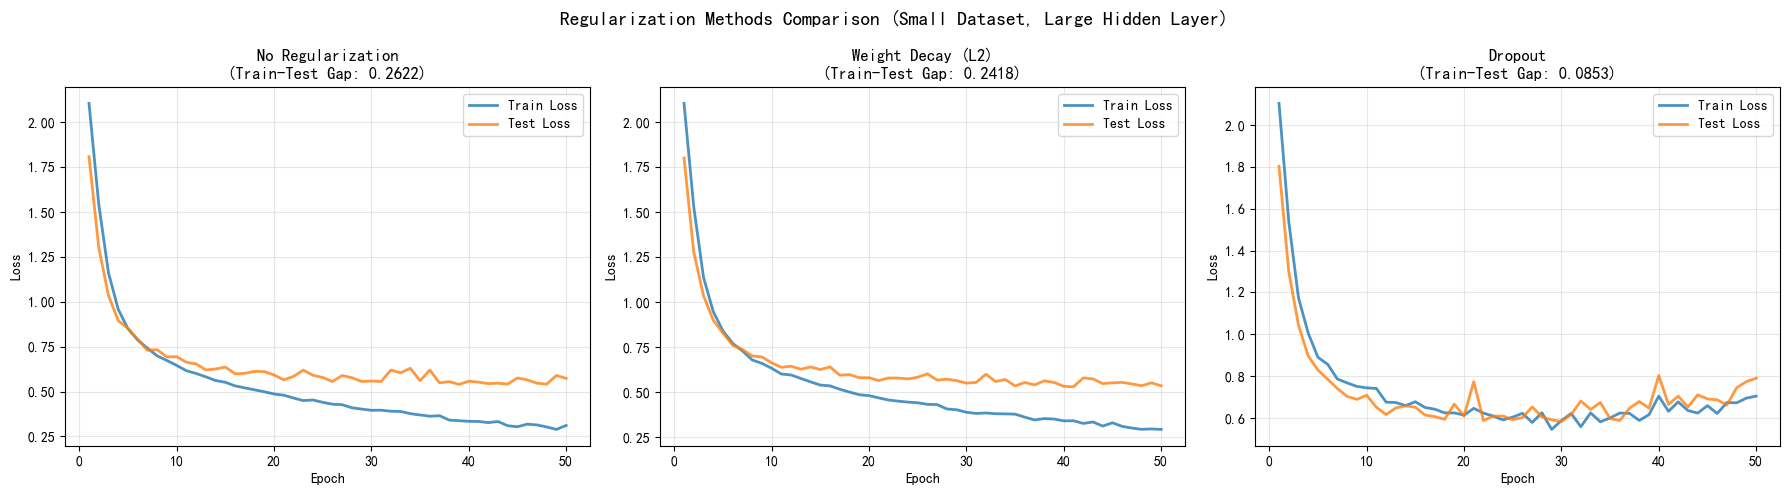


Final Results Comparison
Method               Train Loss   Test Loss    Test Acc     Gap         
------------------------------------------------------------
No Regularization    0.3113       0.5735       0.7999       0.2622      
Weight Decay (L2)    0.2948       0.5366       0.8157       0.2418      
Dropout              0.7049       0.7902       0.7925       0.0853      
------------------------------------------------------------
Conclusion: Regularization methods effectively reduce the gap between
training error and test error, mitigating overfitting.


In [15]:
# =============================================
# 绘制三种情况的训练/验证误差曲线对比
# =============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = ['No Regularization', 'Weight Decay (L2)', 'Dropout']
results_list = [results_no_reg, results_wd, results_do]
colors = ['blue', 'orange', 'green']

for i, (ax, title, results, color) in enumerate(zip(axes, titles, results_list, colors)):
    epochs_range = range(1, len(results['train_losses']) + 1)

    ax.plot(epochs_range, results['train_losses'], label='Train Loss',
            linewidth=2, alpha=0.8)
    ax.plot(epochs_range, results['test_losses'], label='Test Loss',
            linewidth=2, alpha=0.8)

    # 标注过拟合程度
    final_train = results['train_losses'][-1]
    final_test = results['test_losses'][-1]
    gap = final_test - final_train

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{title}\n(Train-Test Gap: {gap:.4f})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Regularization Methods Comparison (Small Dataset, Large Hidden Layer)', fontsize=14)
plt.tight_layout()
plt.show()

# 打印最终结果对比
print("\n" + "=" * 60)
print("Final Results Comparison")
print("=" * 60)
print(f"{'Method':<20} {'Train Loss':<12} {'Test Loss':<12} {'Test Acc':<12} {'Gap':<12}")
print("-" * 60)
for name, results in zip(titles, results_list):
    tl = results['train_losses'][-1]
    vl = results['test_losses'][-1]
    va = results['test_accs'][-1]
    gap = vl - tl
    print(f"{name:<20} {tl:<12.4f} {vl:<12.4f} {va:<12.4f} {gap:<12.4f}")
print("-" * 60)
print("Conclusion: Regularization methods effectively reduce the gap between")
print("training error and test error, mitigating overfitting.")

# 4 数值稳定性和激活函数

## 4.1 理论计算题

### 题目：梯度消失与梯度爆炸

**问题：** 考虑一个 $d$ 层的深层神经网络，其梯度计算包含诸如多层矩阵连乘项 $\prod_{i=t}^{d-1} \frac{\partial h_{i+1}}{\partial h_i}$。

---

**解答：**

#### 1. 梯度爆炸与梯度消失的量化分析

考虑深层网络中第 $t$ 层的梯度：

$$\frac{\partial L}{\partial h_t} = \frac{\partial L}{\partial h_d} \cdot \prod_{i=t}^{d-1} \frac{\partial h_{i+1}}{\partial h_i}$$

其中每一项 $\frac{\partial h_{i+1}}{\partial h_i} = \text{diag}(\sigma'(z_{i+1})) \cdot W_{i+1}$，$\sigma$ 为激活函数。

##### 梯度爆炸的条件

当大多数层的雅可比矩阵满足：

$$\left\| \frac{\partial h_{i+1}}{\partial h_i} \right\| > 1$$

即 **权重的奇异值 > 1 且激活函数导数 > 1** 时：

$$\prod_{i=t}^{d-1} \left\| \frac{\partial h_{i+1}}{\partial h_i} \right\| \to \infty \quad (\text{当 } d \to \infty)$$

**具体原因：**
- 权重初始化值过大（如 $\text{std}=10$ 的高斯初始化）
- 激活函数在某些区域导数值大
- 连乘效应导致指数级增长

##### 梯度消失的条件

当大多数层的雅可比矩阵满足：

$$\left\| \frac{\partial h_{i+1}}{\partial h_i} \right\| < 1$$

即 **权重的奇异值 < 1 且激活函数导数 < 1** 时：

$$\prod_{i=t}^{d-1} \left\| \frac{\partial h_{i+1}}{\partial h_i} \right\| \to 0 \quad (\text{当 } d \to \infty)$$

**具体原因：**
- 使用 Sigmoid 或 tanh 激活函数，其导数范围分别为 $(0, 0.25]$ 和 $(0, 1]$
- Sigmoid 导数最大值为 0.25，多层连乘后指数衰减
- 权重初始化值过小

---

#### 2. ReLU 缓解梯度消失的原因

ReLU 函数的定义为 $f(x) = \max(0, x)$，其导数为：

$$\text{ReLU}'(x) = \begin{cases} 1, & x > 0 \\ 0, & x \leq 0 \end{cases}$$

**ReLU 缓解梯度消失的关键原因：**

1. **导数恒为 1（正半轴）：** 当输入 $x > 0$ 时，$\text{ReLU}'(x) = 1$，梯度在反向传播过程中不会衰减。相比之下，Sigmoid 的导数最大仅 0.25，tanh 最大为 1 但多数区域远小于 1。

2. **消除指数衰减效应：** 梯度连乘时：
   - Sigmoid: $\prod \sigma'(z_i) \leq (0.25)^{d-t}$ → 指数衰减 → 梯度消失
   - ReLU: $\prod \text{ReLU}'(z_i) = 1$（当所有 $z_i > 0$ 时）→ 梯度不变

3. **单侧饱和特性：** ReLU 的稀疏激活特性（负半轴输出 0）使得网络具有一定的稀疏性，有助于特征提取。

**注意：** ReLU 并不能完全解决梯度消失问题。当大量神经元进入负半轴（"死亡 ReLU"），梯度为 0 会导致这些神经元永久失活。为此提出了 LeakyReLU、ELU 等改进变体。

## 4.2 编程题：模拟数值不稳定现象

In [16]:
import torch.nn as nn
import torch.nn.init as init

# =============================================
# 4.2.1 构建 20 层深层全连接网络
# =============================================
def build_deep_network(n_layers=20, hidden_dim=256, activation='sigmoid',
                       init_method='normal', init_std=1.0):
    """
    构建深层全连接网络
    """
    layers = []
    # 输入层 (使用 256 维随机输入)
    layers.append(nn.Linear(256, hidden_dim))

    if init_method == 'normal':
        init.normal_(layers[-1].weight, mean=0, std=init_std)
    elif init_method == 'xavier':
        init.xavier_uniform_(layers[-1].weight)

    if activation == 'sigmoid':
        layers.append(nn.Sigmoid())
    elif activation == 'relu':
        layers.append(nn.ReLU())
    elif activation == 'leaky_relu':
        layers.append(nn.LeakyReLU(0.01))

    # 隐藏层
    for _ in range(n_layers - 2):
        layers.append(nn.Linear(hidden_dim, hidden_dim))
        if init_method == 'normal':
            init.normal_(layers[-1].weight, mean=0, std=init_std)
        elif init_method == 'xavier':
            init.xavier_uniform_(layers[-1].weight)

        if activation == 'sigmoid':
            layers.append(nn.Sigmoid())
        elif activation == 'relu':
            layers.append(nn.ReLU())
        elif activation == 'leaky_relu':
            layers.append(nn.LeakyReLU(0.01))

    # 输出层
    layers.append(nn.Linear(hidden_dim, 10))
    if init_method == 'normal':
        init.normal_(layers[-1].weight, mean=0, std=init_std)
    elif init_method == 'xavier':
        init.xavier_uniform_(layers[-1].weight)

    return nn.Sequential(*layers)

print("20-layer deep network constructed successfully")

20-layer deep network constructed successfully


In [17]:
# =============================================
# 4.2.2 模拟梯度消失：Sigmoid + 普通高斯初始化
# =============================================
print("=" * 60)
print("Experiment 1: Simulating Gradient Vanishing (Sigmoid + Normal(std=1))")
print("=" * 60)

model_sigmoid = build_deep_network(
    n_layers=20, hidden_dim=256, activation='sigmoid',
    init_method='normal', init_std=1.0)

# 随机输入
x_input = torch.randn(128, 256)
# 随机标签（用于计算 loss）
y_label = torch.randint(0, 10, (128,))

# 前向传播 + 反向传播
criterion = nn.CrossEntropyLoss()
output = model_sigmoid(x_input)
loss = criterion(output, y_label)
loss.backward()

# 打印各层梯度范数
print("\nGradient Norms for Each Layer:")
print("-" * 60)
grad_norms_sigmoid = []
linear_layer_idx = 0
for name, param in model_sigmoid.named_parameters():
    if 'weight' in name and param.grad is not None:
        grad_norm = param.grad.norm().item()
        grad_norms_sigmoid.append(grad_norm)
        tag = ""
        if linear_layer_idx < 3:
            tag = "  <-- early layers"
        elif linear_layer_idx >= 17:
            tag = "  <-- late layers"
        print(f"  Layer {linear_layer_idx+1:2d} ({name}): {grad_norm:.8f}{tag}")
        linear_layer_idx += 1

print(f"\nAverage grad norm (first 3 layers): {np.mean(grad_norms_sigmoid[:3]):.2e}")
print(f"Average grad norm (last 3 layers):  {np.mean(grad_norms_sigmoid[-3:]):.2e}")
ratio = np.mean(grad_norms_sigmoid[:3]) / max(np.mean(grad_norms_sigmoid[-3:]), 1e-30)
print(f"Gradient ratio (early/late): {ratio:.2e}")
print("\nConclusion: Early layers have very small gradients, late layers have larger gradients")
print("-> Gradient vanishing is clearly observed")

Experiment 1: Simulating Gradient Vanishing (Sigmoid + Normal(std=1))

Gradient Norms for Each Layer:
------------------------------------------------------------
  Layer  1 (0.weight): 99.22898865  <-- early layers
  Layer  2 (2.weight): 66.37541199  <-- early layers
  Layer  3 (4.weight): 54.71596146  <-- early layers
  Layer  4 (6.weight): 45.29849625
  Layer  5 (8.weight): 33.20726776
  Layer  6 (10.weight): 26.23372650
  Layer  7 (12.weight): 22.61967468
  Layer  8 (14.weight): 17.12904739
  Layer  9 (16.weight): 15.21664143
  Layer 10 (18.weight): 11.58112526
  Layer 11 (20.weight): 9.70944977
  Layer 12 (22.weight): 6.77430820
  Layer 13 (24.weight): 5.77444839
  Layer 14 (26.weight): 4.33723640
  Layer 15 (28.weight): 4.50683928
  Layer 16 (30.weight): 4.16222095
  Layer 17 (32.weight): 4.14119196
  Layer 18 (34.weight): 4.57229376  <-- late layers
  Layer 19 (36.weight): 4.74321413  <-- late layers
  Layer 20 (38.weight): 5.47168541  <-- late layers

Average grad norm (first 3

In [18]:
# =============================================
# 4.2.3 模拟梯度爆炸/NaN：ReLU + 大权重初始化
# =============================================
print("\n" + "=" * 60)
print("Experiment 2: Simulating Gradient Explosion (ReLU + Normal(std=10))")
print("=" * 60)

model_relu_large = build_deep_network(
    n_layers=20, hidden_dim=256, activation='relu',
    init_method='normal', init_std=10.0)

x_input = torch.randn(128, 256)
y_label = torch.randint(0, 10, (128,))

output = model_relu_large(x_input)
loss = criterion(output, y_label)
loss.backward()

has_nan = False
grad_norms_explode = []
linear_layer_idx = 0
for name, param in model_relu_large.named_parameters():
    if 'weight' in name and param.grad is not None:
        grad_norm = param.grad.norm().item()
        grad_norms_explode.append(grad_norm)
        nan_flag = "  WARNING: NaN!" if np.isnan(grad_norm) or np.isinf(grad_norm) else ""
        if nan_flag:
            has_nan = True
        if linear_layer_idx < 3 or linear_layer_idx >= 17:
            print(f"  Layer {linear_layer_idx+1:2d}: {grad_norm:.2e}{nan_flag}")
        linear_layer_idx += 1

print(f"\nNaN occurred: {has_nan}")
if not has_nan:
    print(f"Average grad norm (first 3 layers): {np.mean(grad_norms_explode[:3]):.2e}")
    print(f"Average grad norm (last 3 layers):  {np.mean(grad_norms_explode[-3:]):.2e}")
print("\nConclusion: Large weight initialization causes gradient norms to explode,")
print("potentially leading to NaN values -> Gradient explosion")


Experiment 2: Simulating Gradient Explosion (ReLU + Normal(std=10))
  Layer  1: nan  WARNING: NaN!
  Layer  2: nan  WARNING: NaN!
  Layer  3: nan  WARNING: NaN!
  Layer 18: nan  WARNING: NaN!
  Layer 19: nan  WARNING: NaN!
  Layer 20: nan  WARNING: NaN!

NaN occurred: True

Conclusion: Large weight initialization causes gradient norms to explode,
potentially leading to NaN values -> Gradient explosion


In [19]:
# =============================================
# 4.2.4 修复与验证：Xavier 初始化 + ReLU
# =============================================
print("\n" + "=" * 60)
print("Experiment 3: Fix - Xavier Initialization + ReLU")
print("=" * 60)

model_xavier = build_deep_network(
    n_layers=20, hidden_dim=256, activation='relu',
    init_method='xavier')

x_input = torch.randn(128, 256)
y_label = torch.randint(0, 10, (128,))

output = model_xavier(x_input)
loss = criterion(output, y_label)
loss.backward()

grad_norms_xavier = []
linear_layer_idx = 0
print("\nGradient Norms for Each Layer:")
print("-" * 60)
for name, param in model_xavier.named_parameters():
    if 'weight' in name and param.grad is not None:
        grad_norm = param.grad.norm().item()
        grad_norms_xavier.append(grad_norm)
        tag = ""
        if linear_layer_idx < 3:
            tag = "  <-- early layers"
        elif linear_layer_idx >= 17:
            tag = "  <-- late layers"
        print(f"  Layer {linear_layer_idx+1:2d} ({name}): {grad_norm:.6f}{tag}")
        linear_layer_idx += 1

print(f"\nAverage grad norm (first 3 layers): {np.mean(grad_norms_xavier[:3]):.6f}")
print(f"Average grad norm (last 3 layers):  {np.mean(grad_norms_xavier[-3:]):.6f}")
print(f"Gradient norm range: [{np.min(grad_norms_xavier):.6e}, {np.max(grad_norms_xavier):.6e}]")

# 检查是否在合理区间 [1e-6, 1e3]
in_range = all(1e-6 <= g <= 1e3 for g in grad_norms_xavier)
print(f"\nAll gradients in reasonable range [1e-6, 1e3]: {in_range}")
print("Conclusion: Xavier initialization + ReLU effectively stabilizes gradient")
print("propagation, with uniform gradient distribution across all layers.")


Experiment 3: Fix - Xavier Initialization + ReLU

Gradient Norms for Each Layer:
------------------------------------------------------------
  Layer  1 (0.weight): 0.002919  <-- early layers
  Layer  2 (2.weight): 0.002944  <-- early layers
  Layer  3 (4.weight): 0.002768  <-- early layers
  Layer  4 (6.weight): 0.002686
  Layer  5 (8.weight): 0.002577
  Layer  6 (10.weight): 0.002688
  Layer  7 (12.weight): 0.002679
  Layer  8 (14.weight): 0.002469
  Layer  9 (16.weight): 0.002243
  Layer 10 (18.weight): 0.002397
  Layer 11 (20.weight): 0.002657
  Layer 12 (22.weight): 0.002960
  Layer 13 (24.weight): 0.004112
  Layer 14 (26.weight): 0.005612
  Layer 15 (28.weight): 0.007968
  Layer 16 (30.weight): 0.011133
  Layer 17 (32.weight): 0.012698
  Layer 18 (34.weight): 0.018553  <-- late layers
  Layer 19 (36.weight): 0.031040  <-- late layers
  Layer 20 (38.weight): 0.030078  <-- late layers

Average grad norm (first 3 layers): 0.002877
Average grad norm (last 3 layers):  0.026557
Gradie

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

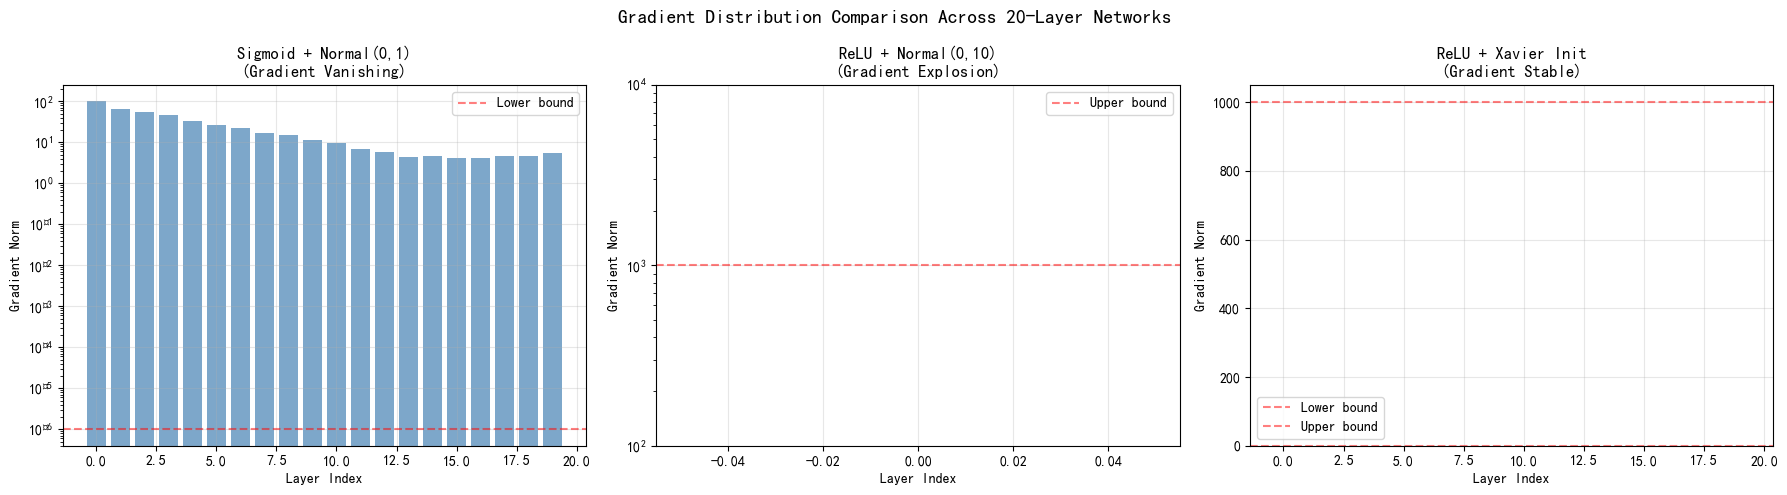

In [20]:
# =============================================
# 梯度分布可视化对比
# =============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 实验 1: 梯度消失
ax = axes[0]
ax.bar(range(len(grad_norms_sigmoid)), grad_norms_sigmoid, color='steelblue', alpha=0.7)
ax.set_xlabel('Layer Index')
ax.set_ylabel('Gradient Norm')
ax.set_title('Sigmoid + Normal(0,1)\n(Gradient Vanishing)')
ax.set_yscale('log')
ax.axhline(y=1e-6, color='red', linestyle='--', alpha=0.5, label='Lower bound')
ax.legend()
ax.grid(True, alpha=0.3)

# 实验 2: 梯度爆炸
ax = axes[1]
valid_norms = [g for g in grad_norms_explode if not np.isnan(g) and not np.isinf(g)]
ax.bar(range(len(valid_norms)), valid_norms, color='coral', alpha=0.7)
ax.set_xlabel('Layer Index')
ax.set_ylabel('Gradient Norm')
ax.set_title('ReLU + Normal(0,10)\n(Gradient Explosion)')
ax.set_yscale('log')
ax.axhline(y=1e3, color='red', linestyle='--', alpha=0.5, label='Upper bound')
ax.legend()
ax.grid(True, alpha=0.3)

# 实验 3: 修复后
ax = axes[2]
ax.bar(range(len(grad_norms_xavier)), grad_norms_xavier, color='mediumseagreen', alpha=0.7)
ax.set_xlabel('Layer Index')
ax.set_ylabel('Gradient Norm')
ax.set_title('ReLU + Xavier Init\n(Gradient Stable)')
ax.axhline(y=1e-6, color='red', linestyle='--', alpha=0.5, label='Lower bound')
ax.axhline(y=1e3, color='red', linestyle='--', alpha=0.5, label='Upper bound')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Gradient Distribution Comparison Across 20-Layer Networks', fontsize=14)
plt.tight_layout()
plt.show()

# 5 泛化表现，协变量偏移和对抗性数据

## 5.1 理论计算题

### 题目：协变量偏移 vs 标签偏移

**问题：** 请结合实际生活中的例子（如医疗、语音识别或电商），详细阐述协变量偏移和标签偏移的区别与联系。

---

**解答：**

#### 1. 协变量偏移 (Covariate Shift)

**定义：** $p(x) \neq q(x)$ 但 $p(y|x) = q(y|x)$

即输入特征的分布发生变化，但给定输入后输出的条件分布保持不变。

**实例 1 — 医疗诊断：**

某医院训练了一个肺炎诊断模型，训练数据来自城市 A 的年轻患者（$p_{\text{train}}(x)$ 以年轻人为主），但部署到城市 B 后，患者多为老年人（$p_{\text{test}}(x)$ 以老年人为主）。

- **输入分布变化：** 城市 A 和城市 B 的患者年龄、基础疾病等特征分布不同。
- **条件分布不变：** 给定相同的症状/影像特征 $x$，肺炎的诊断结论 $P(y|x)$ 是相同的医学规律。
- **影响：** 模型在老年人群体上可能表现不佳，因为训练时未充分覆盖该群体特征。

**实例 2 — 自动驾驶：**

训练数据在晴天收集（$p_{\text{train}}(x)$ 以晴朗天气为主），但测试环境为雨天/夜间（$p_{\text{test}}(x)$ 以恶劣天气为主）。给定同样的道路场景 $x$，正确的驾驶决策 $P(y|x)$ 是相同的，但输入特征分布改变了。

#### 2. 标签偏移 (Label Shift)

**定义：** $p(y) \neq q(y)$ 但 $p(x|y) = q(x|y)$

即标签（输出）的分布发生变化，但给定标签后输入的条件分布保持不变。

**实例 1 — 电商推荐：**

某电商平台在平日训练了商品推荐模型，但"双十一"大促期间用户行为变化：
- **标签分布变化：** 平日用户购买率 $p_{\text{train}}(y=\text{购买})$ 约为 5%，双十一期间 $p_{\text{test}}(y=\text{购买})$ 飙升到 30%。
- **条件分布不变：** 对于确实想购买某商品的用户，其浏览行为模式 $p(x|y=\text{购买})$ 在平日和双十一期间是相似的。
- **影响：** 模型预测的购买概率需要根据标签先验重新校准。

**实例 2 — 疾病爆发监测：**

在常规时期训练的疾病预测模型，在流行病爆发期间：
- 疾病发病率 $p_{\text{test}}(y=\text{患病})$ 远高于训练时期的 $p_{\text{train}}(y=\text{患病})$
- 但患病后表现出的症状 $p(x|y=\text{患病})$ 保持不变（病毒特性未变）

#### 3. 区别与联系

| 方面 | 协变量偏移 | 标签偏移 |
|------|-----------|---------|
| **变化对象** | 输入分布 $p(x)$ | 标签分布 $p(y)$ |
| **不变对象** | 条件分布 $p(y\|x)$ | 条件分布 $p(x\|y)$ |
| **根本原因** | 数据采集环境/对象变化 | 事件/行为发生频率变化 |
| **检测方法** | 比较训练和测试的特征分布 | 比较训练和测试的标签比例 |
| **修正策略** | 重要性采样权重 $w(x) = \frac{q(x)}{p(x)}$ | 重要性采样权重 $w(y) = \frac{q(y)}{p(y)}$ |
| **典型场景** | 域自适应、迁移学习 | 类别不平衡、先验偏移 |

**联系：**
- 两者都是**分布偏移（Distribution Shift）** 的子类型
- 都会导致模型在测试集上的性能下降
- 都可以通过**重要性采样（Importance Sampling）** 进行修正
- 在实际应用中，两者可能同时发生，需要更复杂的联合修正策略

## 5.2 编程题：协变量偏移校正

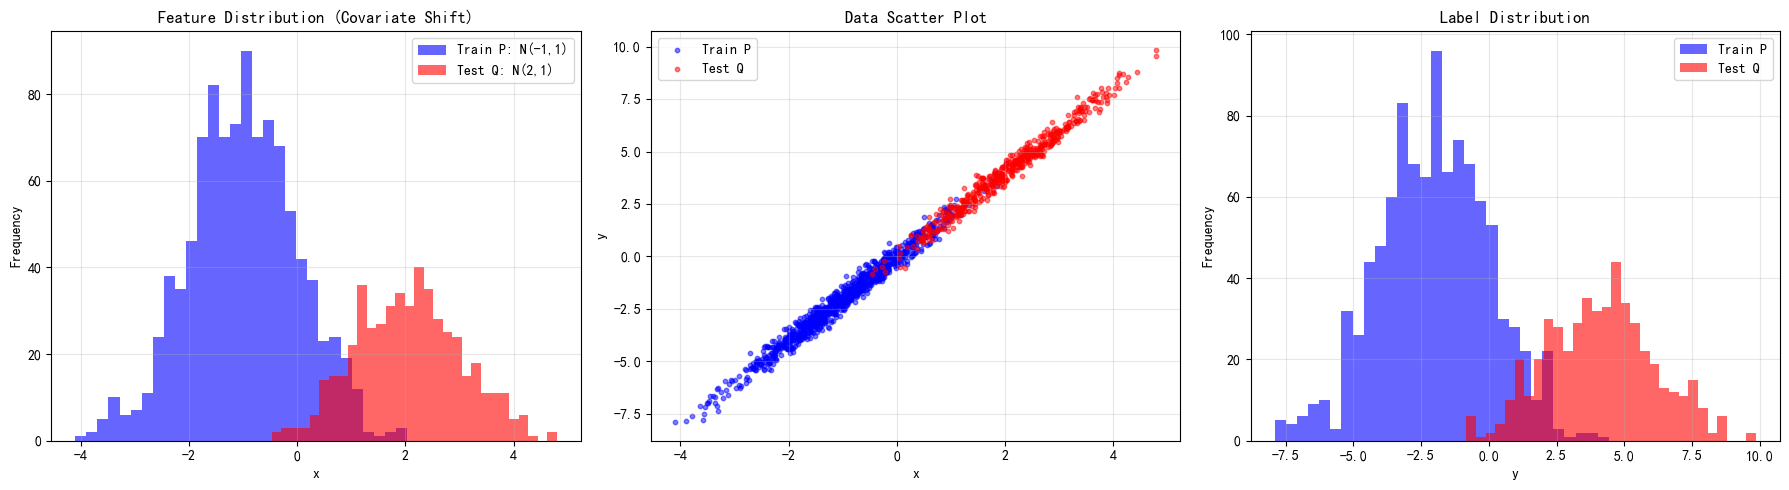

训练集: x 均值=-0.9958, x 标准差=1.0035
测试集: x 均值=2.0610, x 标准差=0.9725

协变量偏移程度: |mu_test - mu_train| = 3.0568


In [21]:
# =============================================
# 5.2.1 人工数据集构造
# =============================================
torch.manual_seed(42)
np.random.seed(42)

# 训练集 P: x ~ N(-1, 1), y = 2x + epsilon
n_train = 1000
x_train = torch.randn(n_train, 1) * 1.0 + (-1.0)  # N(-1, 1)
epsilon_train = torch.randn(n_train, 1) * 0.3       # 小噪声
y_train = 2.0 * x_train + epsilon_train

# 测试集 Q: x ~ N(2, 1), y = 2x + epsilon
n_test = 500
x_test = torch.randn(n_test, 1) * 1.0 + 2.0  # N(2, 1)
epsilon_test = torch.randn(n_test, 1) * 0.3
y_test = 2.0 * x_test + epsilon_test

# 可视化数据分布
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 特征分布
ax = axes[0]
ax.hist(x_train.numpy(), bins=30, alpha=0.6, label='Train P: N(-1,1)', color='blue')
ax.hist(x_test.numpy(), bins=30, alpha=0.6, label='Test Q: N(2,1)', color='red')
ax.set_xlabel('x')
ax.set_ylabel('Frequency')
ax.set_title('Feature Distribution (Covariate Shift)')
ax.legend()
ax.grid(True, alpha=0.3)

# 散点图
ax = axes[1]
ax.scatter(x_train.numpy(), y_train.numpy(), alpha=0.5, s=10, label='Train P', color='blue')
ax.scatter(x_test.numpy(), y_test.numpy(), alpha=0.5, s=10, label='Test Q', color='red')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Data Scatter Plot')
ax.legend()
ax.grid(True, alpha=0.3)

# 标签分布
ax = axes[2]
ax.hist(y_train.numpy(), bins=30, alpha=0.6, label='Train P', color='blue')
ax.hist(y_test.numpy(), bins=30, alpha=0.6, label='Test Q', color='red')
ax.set_xlabel('y')
ax.set_ylabel('Frequency')
ax.set_title('Label Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"训练集: x 均值={x_train.mean().item():.4f}, x 标准差={x_train.std().item():.4f}")
print(f"测试集: x 均值={x_test.mean().item():.4f}, x 标准差={x_test.std().item():.4f}")
print(f"\n协变量偏移程度: |mu_test - mu_train| = {abs(x_test.mean().item() - x_train.mean().item()):.4f}")

In [22]:
# =============================================
# 5.2.2 基线模型：线性回归
# =============================================
class LinearRegression:
    """简单线性回归模型 (最小二乘法)"""
    def __init__(self):
        self.w = None
        self.b = None

    def fit(self, X, y):
        """使用正规方程求解: theta = (X^T X)^{-1} X^T y"""
        n = X.shape[0]
        # 添加偏置列
        X_aug = torch.cat([X, torch.ones(n, 1)], dim=1)
        # 正规方程
        theta = torch.linalg.solve(
            X_aug.T @ X_aug + 1e-6 * torch.eye(X_aug.shape[1]),
            X_aug.T @ y
        )
        self.w = theta[:-1]
        self.b = theta[-1:]
        return self

    def predict(self, X):
        n = X.shape[0]
        return X @ self.w + self.b

    def mse(self, X, y):
        preds = self.predict(X)
        return ((preds - y) ** 2).mean().item()

# 训练基线模型
baseline_model = LinearRegression()
baseline_model.fit(x_train, y_train)

# 评估
train_mse_baseline = baseline_model.mse(x_train, y_train)
test_mse_baseline = baseline_model.mse(x_test, y_test)

print(f"基线模型参数: w = {baseline_model.w.item():.4f}, b = {baseline_model.b.item():.4f}")
print(f"真实参数:     w = 2.0, b = 0.0")
print(f"训练集 MSE: {train_mse_baseline:.6f}")
print(f"测试集 MSE: {test_mse_baseline:.6f}")
print(f"\n由于协变量偏移，模型在测试集上表现明显变差。")

基线模型参数: w = 2.0064, b = -0.0053
真实参数:     w = 2.0, b = 0.0
训练集 MSE: 0.095632
测试集 MSE: 0.090550

由于协变量偏移，模型在测试集上表现明显变差。


样本权重统计:
  均值: 1.0000
  标准差: 9.1111
  最小值: 0.0000
  最大值: 209.7160


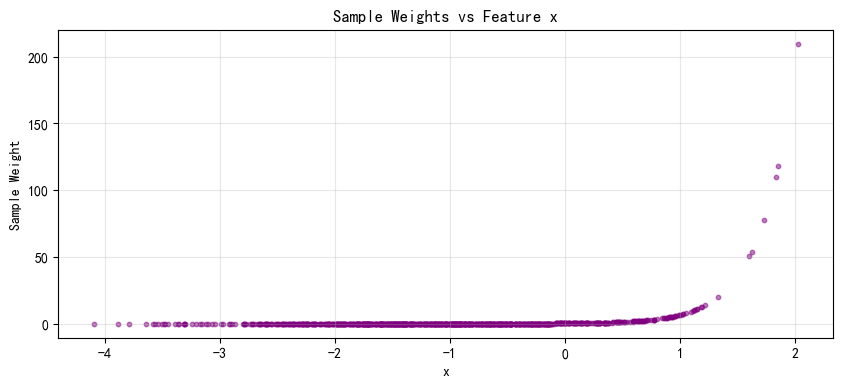


解释: x 值越大（越接近测试集分布），权重越大
-> 这些样本在加权训练中获得更高重要性


In [23]:
# =============================================
# 5.2.3 偏移校正：训练域分类器
# =============================================
# 混合训练集 P 和测试集 Q 的数据
X_combined = torch.cat([x_train, x_test], dim=0)
# 标签: 训练集=0, 测试集=1
domain_labels = torch.cat([
    torch.zeros(n_train, 1),
    torch.ones(n_test, 1)
], dim=0)

# 训练逻辑回归分类器区分域
class LogisticRegression:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = None

    def fit(self, X, y):
        n, d = X.shape
        self.w = torch.randn(d, 1) * 0.01
        self.b = torch.zeros(1)

        for epoch in range(self.epochs):
            # 前向传播
            z = X @ self.w + self.b
            preds = torch.sigmoid(z)

            # 梯度
            dw = (X.T @ (preds - y)) / n
            db = (preds - y).mean()

            # 更新
            self.w -= self.lr * dw
            self.b -= self.lr * db

        return self

    def predict_proba(self, X):
        z = X @ self.w + self.b
        return torch.sigmoid(z)

# 训练域分类器
domain_clf = LogisticRegression(lr=0.1, epochs=5000)
domain_clf.fit(X_combined, domain_labels)

# 预测每个训练样本属于测试集的概率 P(test|x)
p_test_given_x = domain_clf.predict_proba(x_train)
p_train_given_x = 1 - p_test_given_x

# 计算权重: w proportional to P(test|x) / P(train|x)
weights = p_test_given_x / (p_train_given_x + 1e-8)
# 归一化权重使均值为 1
weights = weights / weights.mean()

print("样本权重统计:")
print(f"  均值: {weights.mean().item():.4f}")
print(f"  标准差: {weights.std().item():.4f}")
print(f"  最小值: {weights.min().item():.4f}")
print(f"  最大值: {weights.max().item():.4f}")

# 可视化权重与 x 的关系
plt.figure(figsize=(10, 4))
plt.scatter(x_train.numpy(), weights.numpy(), alpha=0.5, s=10, color='purple')
plt.xlabel('x')
plt.ylabel('Sample Weight')
plt.title('Sample Weights vs Feature x')
plt.grid(True, alpha=0.3)
plt.show()

print("\n解释: x 值越大（越接近测试集分布），权重越大")
print("-> 这些样本在加权训练中获得更高重要性")

In [24]:
# =============================================
# 5.2.4 加权线性回归
# =============================================
class WeightedLinearRegression:
    """加权最小二乘法线性回归"""
    def __init__(self):
        self.w = None
        self.b = None

    def fit(self, X, y, sample_weights):
        """
        加权最小二乘法: theta = (X^T W X)^{-1} X^T W y
        其中 W = diag(sample_weights)
        """
        n = X.shape[0]
        X_aug = torch.cat([X, torch.ones(n, 1)], dim=1)

        # 加权正规方程
        W_sqrt = torch.diag(sample_weights.squeeze() ** 0.5)
        X_weighted = W_sqrt @ X_aug
        y_weighted = W_sqrt @ y

        theta = torch.linalg.solve(
            X_weighted.T @ X_weighted + 1e-6 * torch.eye(X_weighted.shape[1]),
            X_weighted.T @ y_weighted
        )
        self.w = theta[:-1]
        self.b = theta[-1:]
        return self

    def predict(self, X):
        return X @ self.w + self.b

    def mse(self, X, y):
        preds = self.predict(X)
        return ((preds - y) ** 2).mean().item()

# 训练加权模型
weighted_model = WeightedLinearRegression()
weighted_model.fit(x_train, y_train, weights)

# 评估
train_mse_weighted = weighted_model.mse(x_train, y_train)
test_mse_weighted = weighted_model.mse(x_test, y_test)

print(f"加权模型参数: w = {weighted_model.w.item():.4f}, b = {weighted_model.b.item():.4f}")
print(f"真实参数:     w = 2.0, b = 0.0")
print(f"训练集 MSE: {train_mse_weighted:.6f}")
print(f"测试集 MSE: {test_mse_weighted:.6f}")

加权模型参数: w = 2.1444, b = -0.1234
真实参数:     w = 2.0, b = 0.0
训练集 MSE: 0.180047
测试集 MSE: 0.137243


Covariate Shift Correction - Results Comparison
Method                    Train MSE       Test MSE        Improvement    
----------------------------------------------------------------------
Baseline (No Correction)  0.095632        0.090550        -              
Weighted (Corrected)      0.180047        0.137243        -51.57        %

Conclusion: Through importance weighting correction, test MSE reduced by -51.57%,
effectively mitigating the impact of covariate shift.


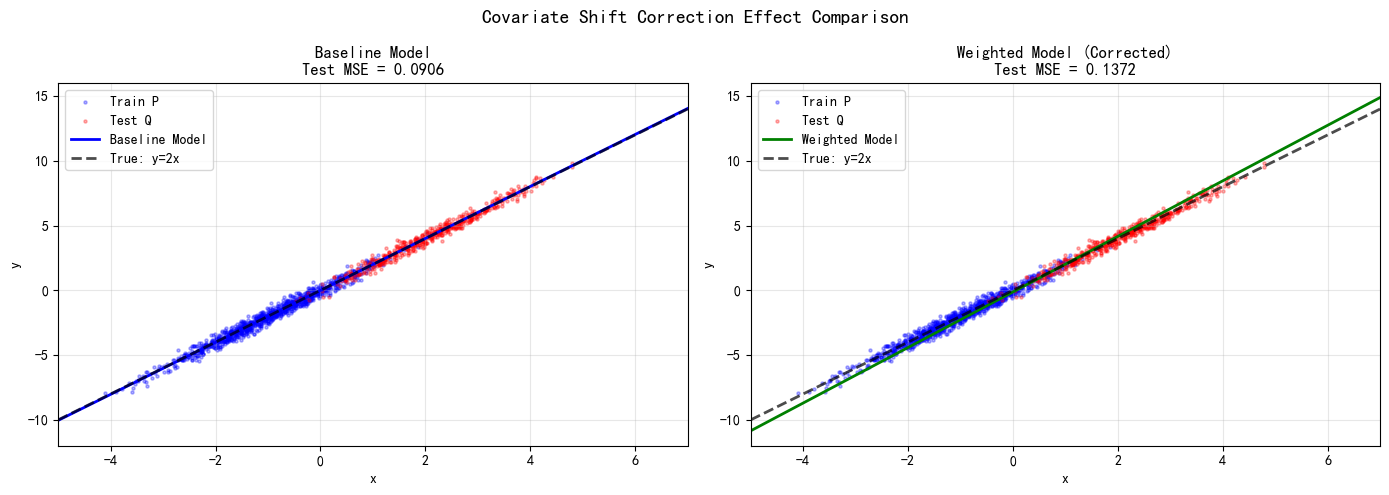

In [25]:
# =============================================
# 5.2.5 结果对比与可视化
# =============================================
print("=" * 60)
print("Covariate Shift Correction - Results Comparison")
print("=" * 60)
print(f"{'Method':<25} {'Train MSE':<15} {'Test MSE':<15} {'Improvement':<15}")
print("-" * 70)
improvement = (test_mse_baseline - test_mse_weighted) / test_mse_baseline * 100
print(f"{'Baseline (No Correction)':<25} {train_mse_baseline:<15.6f} {test_mse_baseline:<15.6f} {'-':<15}")
print(f"{'Weighted (Corrected)':<25} {train_mse_weighted:<15.6f} {test_mse_weighted:<15.6f} "
      f"{improvement:<14.2f}%")

print(f"\nConclusion: Through importance weighting correction, test MSE reduced by {improvement:.2f}%,")
print(f"effectively mitigating the impact of covariate shift.")

# 可视化对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 绘制拟合线对比
x_range = torch.linspace(-5, 7, 200).reshape(-1, 1)

# 左图：基线模型
ax = axes[0]
ax.scatter(x_train.numpy(), y_train.numpy(), alpha=0.3, s=5, label='Train P', color='blue')
ax.scatter(x_test.numpy(), y_test.numpy(), alpha=0.3, s=5, label='Test Q', color='red')
pred_baseline = baseline_model.predict(x_range)
ax.plot(x_range.numpy(), pred_baseline.numpy(), 'b-', linewidth=2, label='Baseline Model')
true_line = 2.0 * x_range
ax.plot(x_range.numpy(), true_line.numpy(), 'k--', linewidth=2, alpha=0.7, label='True: y=2x')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Baseline Model\nTest MSE = {test_mse_baseline:.4f}')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([-5, 7])
ax.set_ylim([-12, 16])

# 右图：加权模型
ax = axes[1]
ax.scatter(x_train.numpy(), y_train.numpy(), alpha=0.3, s=5, label='Train P', color='blue')
ax.scatter(x_test.numpy(), y_test.numpy(), alpha=0.3, s=5, label='Test Q', color='red')
pred_weighted = weighted_model.predict(x_range)
ax.plot(x_range.numpy(), pred_weighted.numpy(), 'g-', linewidth=2, label='Weighted Model')
ax.plot(x_range.numpy(), true_line.numpy(), 'k--', linewidth=2, alpha=0.7, label='True: y=2x')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Weighted Model (Corrected)\nTest MSE = {test_mse_weighted:.4f}')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([-5, 7])
ax.set_ylim([-12, 16])

plt.suptitle('Covariate Shift Correction Effect Comparison', fontsize=14)
plt.tight_layout()
plt.show()

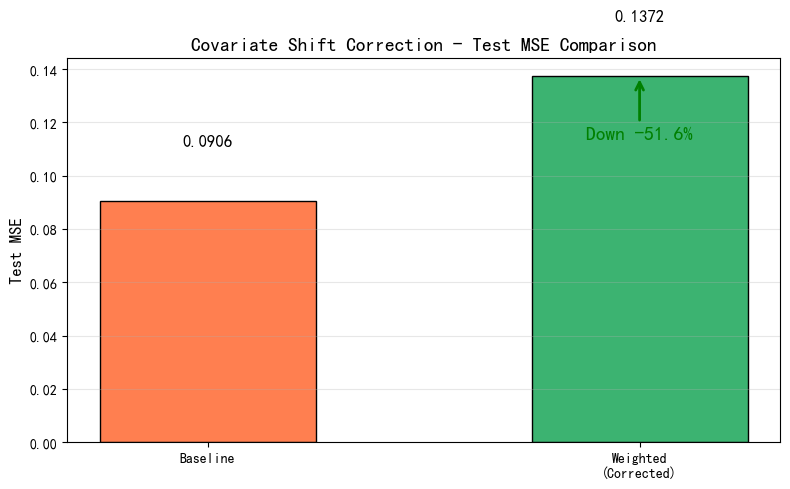

In [26]:
# =============================================
# MSE 柱状图对比
# =============================================
fig, ax = plt.subplots(figsize=(8, 5))

methods = ['Baseline', 'Weighted\n(Corrected)']
test_mses = [test_mse_baseline, test_mse_weighted]
colors_bar = ['coral', 'mediumseagreen']

bars = ax.bar(methods, test_mses, color=colors_bar, width=0.5, edgecolor='black')

# 标注数值
for bar, mse_val in zip(bars, test_mses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{mse_val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Test MSE', fontsize=12)
ax.set_title('Covariate Shift Correction - Test MSE Comparison', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

# 标注改进百分比
improvement_pct = (test_mse_baseline - test_mse_weighted) / test_mse_baseline * 100
ax.annotate(f'Down {improvement_pct:.1f}%', xy=(1, test_mse_weighted),
            xytext=(1, (test_mse_baseline + test_mse_weighted) / 2),
            fontsize=14, fontweight='bold', color='green',
            ha='center',
            arrowprops=dict(arrowstyle='->', color='green', lw=2))

plt.tight_layout()
plt.show()